# 04 — Classification Modeling

Predict low / medium / high usage categories derived from average utilization thresholds (<0.30, 0.30–0.60, >0.60) and compare linear, tree/boosting, and neural classifiers.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if (ROOT / "rec_center_utils.py").exists():
    pass
elif (ROOT / "rec_center" / "rec_center_utils.py").exists():
    ROOT = ROOT / "rec_center"
elif (ROOT.parent / "rec_center_utils.py").exists():
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not locate rec_center_utils.py")
sys.path.insert(0, str(ROOT))

from rec_center_utils import (
    TRAIN_END,
    VAL_END,
    clean_data,
    data_path,
    figures_path,
    load_clean_data,
    load_raw_data,
    save_clean_data,
)

sns.set_theme(style="whitegrid", context="notebook")

import numpy as np
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

from rec_center_utils import CLASS_HIGH, CLASS_LOW, RANDOM_STATE, get_feature_frame



c:\Users\tyler\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:

df = load_clean_data()
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "validation"]
test_df = df[df["split"] == "test"]

le = LabelEncoder()
le.fit(df["usage_level"].astype(str))
y_train = le.transform(train_df["usage_level"].astype(str))
y_val = le.transform(val_df["usage_level"].astype(str))
y_test = le.transform(test_df["usage_level"].astype(str))

feature_cols = get_feature_frame(train_df).columns.tolist()
numeric_cols = [c for c in feature_cols if c != "location"]
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["location"]),
    ("num", "passthrough", numeric_cols),
])

X_train = get_feature_frame(train_df)
X_val = get_feature_frame(val_df)
X_test = get_feature_frame(test_df)
preprocessor.fit(X_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(preprocessor.transform(X_train))
X_test_scaled = scaler.transform(preprocessor.transform(X_test))

print(f"Thresholds: low < {CLASS_LOW}, high > {CLASS_HIGH}")



Thresholds: low < 0.3, high > 0.6


## Model comparison


In [3]:

results = []

logistic = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
logistic.fit(X_train, y_train)
log_pred = logistic.predict(X_test)
results.append({"model": "logistic_regression", "accuracy": accuracy_score(y_test, log_pred), "macro_f1": f1_score(y_test, log_pred, average="macro")})

rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_search = RandomizedSearchCV(rf, {"model__n_estimators": [200, 300], "model__max_depth": [8, 12, None], "model__min_samples_leaf": [1, 2, 5]}, n_iter=10, scoring="f1_macro", cv=3, random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
rf_pred = rf_best.predict(X_test)
results.append({"model": "random_forest", "accuracy": accuracy_score(y_test, rf_pred), "macro_f1": f1_score(y_test, rf_pred, average="macro")})

lgbm = Pipeline([
    ("prep", preprocessor),
    ("model", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
])
lgbm_search = RandomizedSearchCV(lgbm, {"model__n_estimators": [200, 400], "model__learning_rate": [0.05, 0.1], "model__num_leaves": [31, 63]}, n_iter=10, scoring="f1_macro", cv=3, random_state=RANDOM_STATE, n_jobs=-1)
lgbm_search.fit(X_train, y_train)
lgbm_best = lgbm_search.best_estimator_
lgbm_pred = lgbm_best.predict(X_test)
results.append({"model": "lightgbm", "accuracy": accuracy_score(y_test, lgbm_pred), "macro_f1": f1_score(y_test, lgbm_pred, average="macro")})

cat = Pipeline([
    ("prep", preprocessor),
    ("model", CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)),
])
cat_search = RandomizedSearchCV(cat, {"model__depth": [6, 8], "model__learning_rate": [0.05, 0.1], "model__iterations": [300, 500]}, n_iter=8, scoring="f1_macro", cv=3, random_state=RANDOM_STATE, n_jobs=-1)
cat_search.fit(X_train, y_train)
cat_best = cat_search.best_estimator_
cat_pred = cat_best.predict(X_test)
results.append({"model": "catboost", "accuracy": accuracy_score(y_test, cat_pred), "macro_f1": f1_score(y_test, cat_pred, average="macro")})

import optuna
import tensorflow as tf
from tensorflow.keras import layers

optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.keras.utils.set_random_seed(RANDOM_STATE)

def build_classifier(params):
    model = tf.keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(params["units_1"], activation="relu"),
        layers.Dropout(params["dropout"]),
        layers.Dense(params["units_2"], activation="relu"),
        layers.Dense(len(le.classes_), activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(params["learning_rate"]), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def cls_objective(trial):
    params = {
        "units_1": trial.suggest_int("units_1", 32, 128, step=32),
        "units_2": trial.suggest_int("units_2", 16, 64, step=16),
        "dropout": trial.suggest_float("dropout", 0.1, 0.4),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True),
    }
    model = build_classifier(params)
    model.fit(X_train_scaled, y_train, validation_data=(scaler.transform(preprocessor.transform(X_val)), y_val), epochs=12, batch_size=1024, verbose=0)
    preds = model.predict(scaler.transform(preprocessor.transform(X_val)), verbose=0).argmax(axis=1)
    return 1 - f1_score(y_val, preds, average="macro")

cls_study = optuna.create_study(direction="minimize")
cls_study.optimize(cls_objective, n_trials=8)
nn_cls = build_classifier(cls_study.best_params)
nn_cls.fit(X_train_scaled, y_train, validation_data=(scaler.transform(preprocessor.transform(X_val)), y_val), epochs=15, batch_size=1024, verbose=0)
nn_pred = nn_cls.predict(X_test_scaled, verbose=0).argmax(axis=1)
results.append({"model": "keras_mlp", "accuracy": accuracy_score(y_test, nn_pred), "macro_f1": f1_score(y_test, nn_pred, average="macro")})

classification_table = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
classification_table



c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,macro_f1
3,catboost,0.819014,0.792792
2,lightgbm,0.813401,0.787213
1,random_forest,0.813054,0.784233
4,keras_mlp,0.793462,0.765705
0,logistic_regression,0.709478,0.658014


## Confusion matrix for best gradient boosting classifier


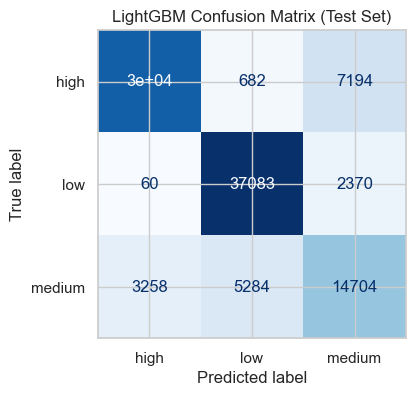

In [4]:

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, lgbm_pred, display_labels=le.classes_, cmap="Blues", ax=ax, colorbar=False)
ax.set_title("LightGBM Confusion Matrix (Test Set)")
fig.savefig(figures_path("classification_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()



### Metric justification

- **Macro-F1** is the primary metric because it treats low/medium/high classes equally.
- **Accuracy** is reported for business readability but can hide poor performance on high-crowd periods.
